(6, 2)
X:  [[1.  1.4]
 [1.  1. ]
 [1.  1.5]
 [1.  3. ]
 [1.  3.8]
 [1.  4.1]]
y:  [0. 0. 0. 1. 1. 1.]


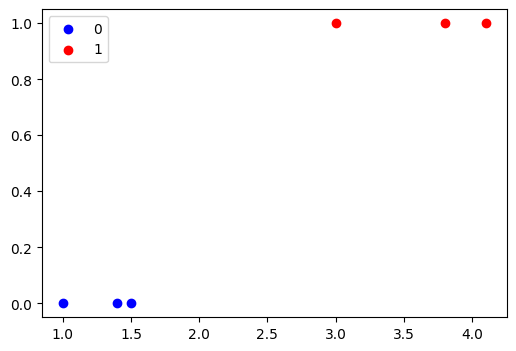

In [1]:
import numpy as np
import matplotlib.pyplot as plt

iris = np.genfromtxt('iris_1D.csv', dtype=None, delimiter=',', skip_header=1) 
print(iris.shape)
X = iris[:, :1]
y = iris[:, 1]
N = 6

plt.figure(figsize=(6, 4))
plt.scatter(X[y == 0][:, 0], y[y == 0], color='b', label='0')
plt.scatter(X[y == 1][:, 0], y[y == 1], color='r', label='1')
plt.legend()

intercept = np.ones((X.shape[0], 1))
X = np.concatenate((intercept, X), axis=1)

print('X: ', X)
print('y: ', y)

In [2]:
def sigmoid_function(z):
    return 1 / (1 + np.exp(-z))

def loss_function(y_hat, y):
    return -y * np.log(y_hat) - (1 - y) * np.log(1 - y_hat)

def predict(X, theta):    
    y_hat = sigmoid_function(np.dot(X, theta))
    return y_hat

def compute_gradient(x, y_hat, y):
    return x*(y_hat - y)

lr = 0.01
num_iter = 5000

#theta = np.array([0.01, -0.01])
#theta = np.array([0.1, 5])
theta = np.array([0.1, -5])

losses = []
accs   = []

for _ in range(num_iter):
    # for each sample
    for i in range(N):
        # get a sample
        xi = X[i]
        yi = y[i]
        
        # predict z
        y_hat = predict(xi, theta)
        
        # compute loss
        loss = loss_function(y_hat, yi)
    
        # compute gradient and update
        gradient = compute_gradient(xi, y_hat, yi)        
        theta -= lr*gradient 
    
        # for debug
        losses.append(loss)
    
    # accuracy for training
    preds = predict(X, theta).round()
    acc = (preds == y).mean()
    accs.append(acc)  

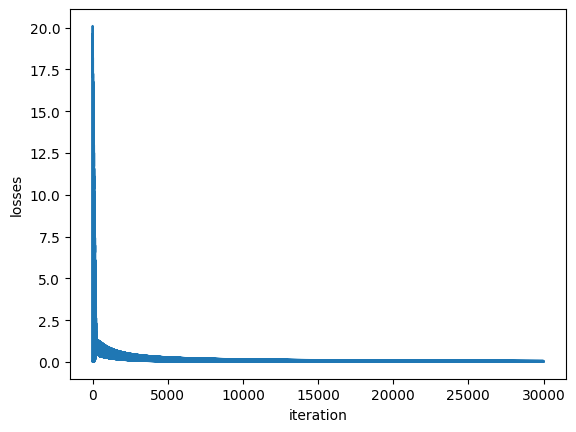

In [3]:
import matplotlib.pyplot as plt

plt.plot(losses[1:])
plt.xlabel('iteration')
plt.ylabel('losses')
plt.show()

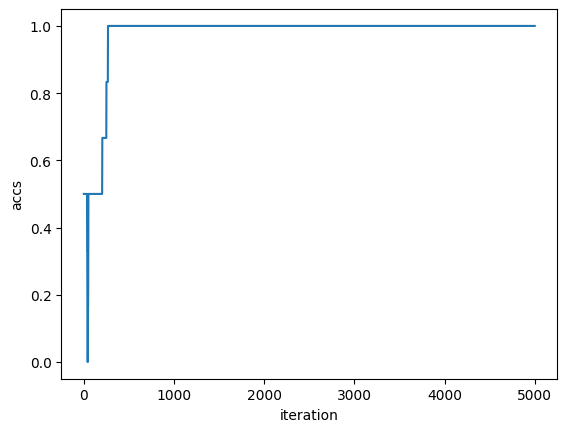

In [4]:
import matplotlib.pyplot as plt

plt.plot(accs[1:])
plt.xlabel('iteration')
plt.ylabel('accs')
plt.show()